In [3]:
import matplotlib.pyplot as plt
import numpy as np
import dask
import xarray as xr
import rioxarray as rxr
import cartopy.crs as ccrs

In [4]:
rsut_ds = xr.open_dataset(
    "/Users/filipnovak/Documents/ML_geosciences/CanESM5_1850-2100_rsut.nc",
    engine="netcdf4",
    chunks={"time": 12},
    decode_times=True,
    use_cftime=True
)

rsutcs_ds = xr.open_dataset(
    "/Users/filipnovak/Downloads/CanESM_1850-2100_rsutcs.nc",
    engine="netcdf4",
    chunks={"time": 12},
    decode_times=True,
    use_cftime=True
)

# Merge into one dataset
ESM5_data = xr.merge([rsut_ds, rsutcs_ds])

/var/folders/g2/cdqgt5_n6_qgq1m_sjk9x3r00000gn/T/ipykernel_5539/2508233126.py:1: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  rsut_ds = xr.open_dataset(
/var/folders/g2/cdqgt5_n6_qgq1m_sjk9x3r00000gn/T/ipykernel_5539/2508233126.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 12. This could degrade performance. Instead, consider rechunking after loading.
  rsut_ds = xr.open_dataset(
/var/folders/g2/cdqgt5_n6_qgq1m_sjk9x3r00000gn/T/ipykernel_5539/2508233126.py:9: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatet

<xarray.DataArray (member: 25, time: 3012, lat: 64, lon: 128)> Size: 2GB
dask.array<sub, shape=(25, 3012, 64, 128), dtype=float32, chunksize=(5, 12, 16, 32), chunktype=numpy.ndarray>
Coordinates:
  * member   (member) int64 200B 0 1 2 3 4 5 6 7 8 ... 17 18 19 20 21 22 23 24
  * time     (time) object 24kB 1850-01-16 12:00:00 ... 2100-12-16 12:00:00
  * lat      (lat) float64 512B -87.86 -85.1 -82.31 -79.53 ... 82.31 85.1 87.86
  * lon      (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2
Attributes:
    units:          W m-2
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    history:        2019-07-06T01:28:30Z altered by CMOR: Reordered dimension...


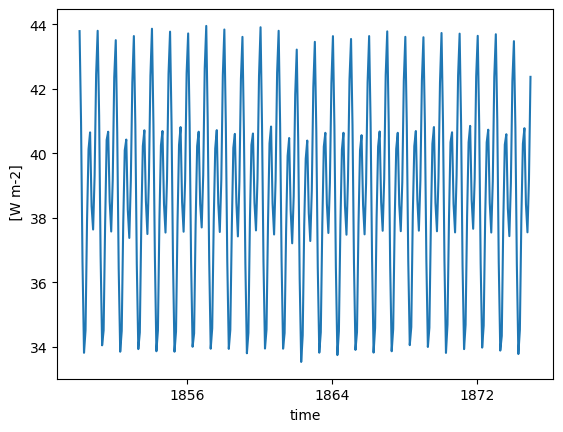

In [5]:
# Select variables
rsut = ESM5_data["rsut"]
rsutcs = ESM5_data["rsutcs"]

# Compute shortwave Cloud Radiative Effect
swcre = rsut - rsutcs

# Quick dataset check
print(swcre)

# Global mean time series (first 300 months)
test_series = (
    swcre
    .mean(["lat", "lon", "member"])
    .isel(time=slice(0, 300))
    .compute()
)

test_series.plot()

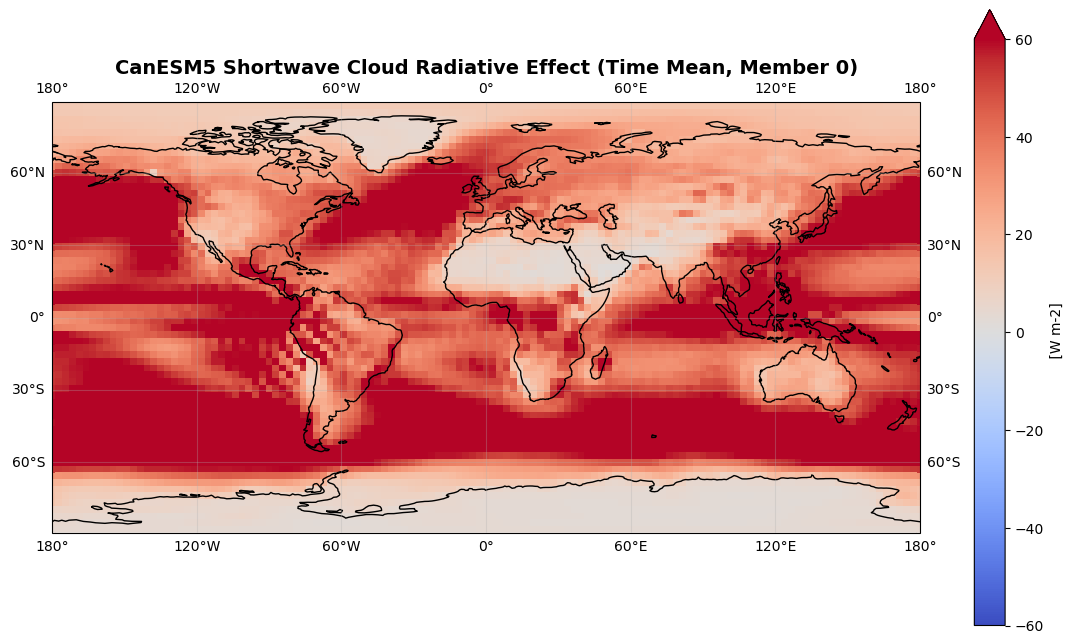

In [6]:
# Compute shortwave Cloud Radiative Effect
swcre = ESM5_data["rsut"] - ESM5_data["rsutcs"]

# Time mean and select member 0
map_da = swcre
if "time" in map_da.dims:
    map_da = map_da.mean("time")
if "member" in map_da.dims:
    map_da = map_da.isel(member=0)

# Plot
fig = plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(linewidth=1)
ax.gridlines(draw_labels=True, alpha=0.3)

map_da.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="coolwarm",
    vmin=-60,
    vmax=60,
    x="lon",
    y="lat"
)

plt.title("CanESM5 Shortwave Cloud Radiative Effect (Time Mean, Member 0)",
          fontsize=14, fontweight="bold")

plt.show()

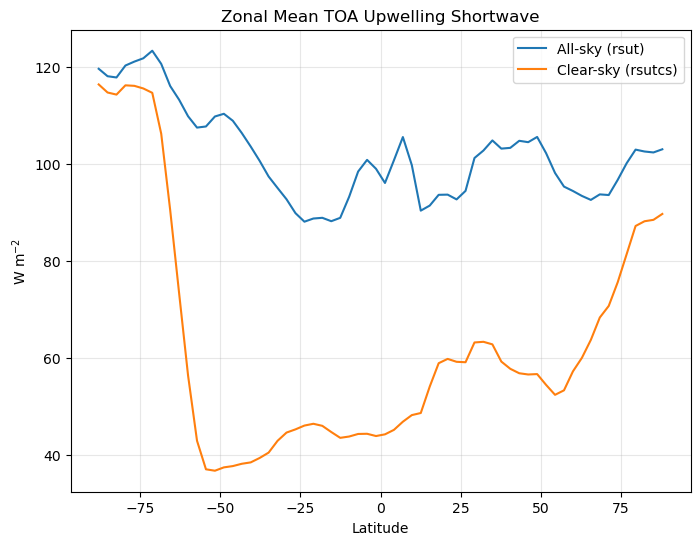

In [7]:
rsut = ESM5_data["rsut"]
rsutcs = ESM5_data["rsutcs"]

# Reduce time and member dimensions first
if "time" in rsut.dims:
    rsut = rsut.mean("time")
if "member" in rsut.dims:
    rsut = rsut.mean("member")

if "time" in rsutcs.dims:
    rsutcs = rsutcs.mean("time")
if "member" in rsutcs.dims:
    rsutcs = rsutcs.mean("member")

# Compute zonal mean
rsut_zonal = rsut.mean("lon")
rsutcs_zonal = rsutcs.mean("lon")

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
rsut_zonal.plot(label="All-sky (rsut)")
rsutcs_zonal.plot(label="Clear-sky (rsutcs)")
plt.legend()
plt.title("Zonal Mean TOA Upwelling Shortwave")
plt.xlabel("Latitude")
plt.ylabel("W m$^{-2}$")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
rsut_var = "rlut" if "rlut" in rsut_ds.data_vars else list(rsut_ds.data_vars)[0]
rsutcs_var = "rlutcs" if "rlutcs" in rsutcs_ds.data_vars else list(rsutcs_ds.data_vars)[0]

rsut_da = rsut_ds[rsut_var]
rsutcs_da = rsutcs_ds[rsutcs_var]

# Align in case of coordinate differences
rsut_da, rsutcs_da = xr.align(rsut_da, rsutcs_da, join="inner")

rsut_da = rsut_da.chunk({"time": 12, "lat": -1, "lon": -1})
rsutcs_da = rsutcs_da.chunk({"time": 12, "lat": -1, "lon": -1})

# Annual mean FIRST (shrinks time dimension massively)
rsut_ann = rsut_da.groupby("time.year").mean("time")
rsutcs_ann = rsutcs_da.groupby("time.year").mean("time")

# Ensemble mean
if "member" in rsut_ann.dims:
    rsut_ann = rsut_ann.mean("member")
    rsutcs_ann = rsutcs_ann.mean("member")

# Subtract (now much smaller)
swcre = rsut_ann - rsutcs_ann

# rechunk spatial dims into single chunks
swcre = swcre.chunk({"lat": -1, "lon": -1})

# Area weights
weights = np.cos(np.deg2rad(swcre.lat))

# Global mean
swcre_global = swcre.weighted(weights).mean(("lat", "lon")).compute()

import numpy as np
import matplotlib.pyplot as plt

years = swcre_global.year.values
values = swcre_global.values

# Fit linear trend
coef = np.polyfit(years, values, 1)
trend = np.poly1d(coef)

# Plot
plt.figure(figsize=(10,5))
plt.plot(years, values, label="Annual Mean SW CRE")
plt.plot(years, trend(years), "r--", linewidth=2, label="Linear Trend")

plt.title("Global Mean SW CRE (Annual) with Trend")
plt.xlabel("Year")
plt.ylabel("W m$^{-2}$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Trend = {coef[0]:.4f} W/m² per year")
print(f"Trend per decade = {coef[0]*10:.4f} W/m² per decade")